In [1]:
import json
import os
import pandas as pd

In [2]:

files = [
    "datasets/problem.json",
    "datasets/student-problem-middle.json"
]
base_path = "/Users/muazalbaghdadi/Documents/Work/Reasearch/UDST/Gamification/MOOCRadar"

In [3]:
df_problems = pd.read_json(os.path.join(base_path, files[0]), lines=True)

# Loading Middle to DF
file_path = os.path.join(base_path, files[1])
# Load and flatten the nested JSON sequences
with open(file_path, "r", encoding="utf-8") as f:
    student_data = json.load(f)
# Flatten the nested "seq" list for each student
df_middle = pd.json_normalize(student_data, record_path="seq")

In [4]:
print('df_problems info and head')
df_problems.info()
df_problems.head()

df_problems info and head
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9383 entries, 0 to 9382
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   problem_id           9383 non-null   object
 1   exercise_id          9383 non-null   object
 2   course_id            9383 non-null   object
 3   detail               9383 non-null   object
 4   knowledge_type       9383 non-null   int64 
 5   cognitive_dimension  9383 non-null   int64 
 6   concepts             9383 non-null   object
dtypes: int64(2), object(5)
memory usage: 513.3+ KB


,problem_id,exercise_id,course_id,detail,knowledge_type,cognitive_dimension,concepts
0,Pm_2046133,Ex_1641736,C_674920,"{'problem_id': 2046133, 'title': '第一章作业', 'con...",2,4,"[经济发展逻辑, 逻辑学]"
1,Pm_2046134,Ex_1641736,C_674920,"{'problem_id': 2046134, 'title': '第一章作业', 'con...",2,2,"[希腊语, 逻辑]"
2,Pm_2046135,Ex_1641736,C_674920,"{'problem_id': 2046135, 'title': '第一章作业', 'con...",2,2,"[逻辑, 推理]"
3,Pm_2046136,Ex_1641736,C_674920,"{'problem_id': 2046136, 'title': '第一章作业', 'con...",2,2,"[演绎推理, 推理, 结论]"
4,Pm_2046137,Ex_1641736,C_674920,"{'problem_id': 2046137, 'title': '第一章作业', 'con...",2,2,"[命题, 有效推理形式]"


In [5]:
print('df_problems info and head')
df_middle.info()
df_middle.head()

df_problems info and head
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898933 entries, 0 to 898932
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   log_id       898933 non-null  object 
 1   problem_id   898933 non-null  object 
 2   user_id      898933 non-null  object 
 3   is_correct   898933 non-null  int64  
 4   attempts     898933 non-null  int64  
 5   score        355086 non-null  float64
 6   submit_time  898933 non-null  object 
 7   skill_id     898933 non-null  object 
 8   exercise_id  898933 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 61.7+ MB


,log_id,problem_id,user_id,is_correct,attempts,score,submit_time,skill_id,exercise_id
0,1002476_5940094,Pm_668265,U_1002476,1,1,NaN,2020-12-13 12:02:59,Ex_535149,Ex_535149
1,1002476_5940096,Pm_668266,U_1002476,1,1,NaN,2020-12-13 12:03:11,Ex_535149,Ex_535149
2,1002476_5940097,Pm_668267,U_1002476,1,1,NaN,2020-12-13 12:03:18,Ex_535149,Ex_535149
3,1002476_5940102,Pm_668268,U_1002476,1,1,NaN,2020-12-13 12:11:10,Ex_535150,Ex_535150
4,1002476_5940103,Pm_668269,U_1002476,1,1,NaN,2020-12-13 12:11:21,Ex_535150,Ex_535150


# Data Aggregation.

In [6]:
# 1. Merge the interaction logs with the problem metadata
df_merged = pd.merge(
    df_middle, 
    df_problems, 
    on=['problem_id', 'exercise_id'], 
    how='left'
)

In [7]:
# 2. Convert 'submit_time' from string to a datetime object
# (This is mandatory for calculating the Temporal Features in Phase 2)
df_merged['submit_time'] = pd.to_datetime(df_merged['submit_time'])

In [8]:
# 3. Sort the data chronologically per student
# (Crucial so that 'time between attempts' and 'course jumping' calculate in the right order)
df_merged = df_merged.sort_values(by=['user_id', 'submit_time']).reset_index(drop=True)

In [11]:
# Verify the merge
print("Merged Data Shape:", df_merged.shape)
print("\nColumns available for Feature Engineering:")
print(df_merged.columns.tolist())

Merged Data Shape: (898933, 14)

Columns available for Feature Engineering:
['log_id', 'problem_id', 'user_id', 'is_correct', 'attempts', 'score', 'submit_time', 'skill_id', 'exercise_id', 'course_id', 'detail', 'knowledge_type', 'cognitive_dimension', 'concepts']


# Phase 2: Behavioral Feature Engineering.

In [12]:
import numpy as np

In [13]:
print("Engineering behavioral features...")

# --- PRE-COMPUTATIONS ---
# Calculate time gap between actions for each user
df_merged['time_diff'] = df_merged.groupby('user_id')['submit_time'].diff().dt.total_seconds()

# Calculate "course jumps" (when a user switches to a different exercise)
df_merged['exercise_jump'] = (df_merged.groupby('user_id')['exercise_id'].shift() != df_merged['exercise_id']).astype(int)

# Identify high cognitive tasks (Bloom's level 4, 5, 6)
df_merged['is_high_cog'] = df_merged['cognitive_dimension'] >= 4

Engineering behavioral features...


# --- AGGREGATION ---

In [21]:

# Group by user to create the student-centric dataframe
df_aggregated = df_merged.groupby('user_id').agg(
    
    # 1. Temporal Features
    median_time_between_attempts=('time_diff', 'median'),
    active_days_count=('submit_time', lambda x: x.dt.date.nunique()),
    
    # 2. Effort & Tenacity Features
    total_attempts=('attempts', 'sum'),
    unique_problems=('problem_id', 'nunique'),
    abandonment_count=('is_correct', lambda x: (x == 0).sum()), # Count of failed interactions
    
    # 3. Cognitive & Strategy Features
    avg_cognitive_dimension=('cognitive_dimension', 'mean'),
    score_maximization_ratio=('score', lambda x: (x == 1.0).mean()), # How often they get a perfect score
    
    # 4. Exploration Features
    course_jumping_index=('exercise_jump', 'sum')
).reset_index()



# --- POST-COMPUTATIONS (Ratios & Adjustments) ---


In [22]:

# Adjust jumps (subtract 1 because the very first exercise shouldn't count as a jump)
df_aggregated['course_jumping_index'] = np.maximum(0, df_aggregated['course_jumping_index'] - 1)

# Average attempts per problem (Effort)
df_aggregated['avg_attempts_per_problem'] = df_aggregated['total_attempts'] / df_aggregated['unique_problems']

# Abandonment Rate (Percentage of interactions that ended in failure)
df_aggregated['abandonment_rate'] = df_aggregated['abandonment_count'] / df_aggregated['total_attempts']

# Drop intermediate columns we used for math
df_aggregated = df_aggregated.drop(columns=['total_attempts', 'unique_problems', 'abandonment_count'])

# Fill any NaN values (e.g., users with only 1 interaction won't have a 'time_diff')
df_aggregated = df_aggregated.fillna(0)

print("Student-Centric Hexad dataset created!")
print("Shape:", df_aggregated.shape)
print(df_aggregated.head())

Student-Centric Hexad dataset created!
Shape: (14224, 8)
      user_id  median_time_between_attempts  active_days_count  \
0   U_1002476                          29.5                  1   
1  U_10032370                          64.0                  7   
2   U_1006467                          48.0                  7   
3   U_1006581                         209.0                  7   
4   U_1007135                          39.0                  1   

   avg_cognitive_dimension  score_maximization_ratio  course_jumping_index  \
0                 1.960000                  0.000000                    11   
1                 3.000000                  0.000000                     8   
2                 2.114286                  0.828571                    33   
3                 2.114286                  0.842857                    34   
4                 1.571429                  0.285714                     7   

   avg_attempts_per_problem  abandonment_rate  
0                       1.0  

In [24]:
df_aggregated.dtypes

user_id                          object
median_time_between_attempts    float64
active_days_count                 int64
avg_cognitive_dimension         float64
score_maximization_ratio        float64
course_jumping_index              int64
avg_attempts_per_problem        float64
abandonment_rate                float64
dtype: object

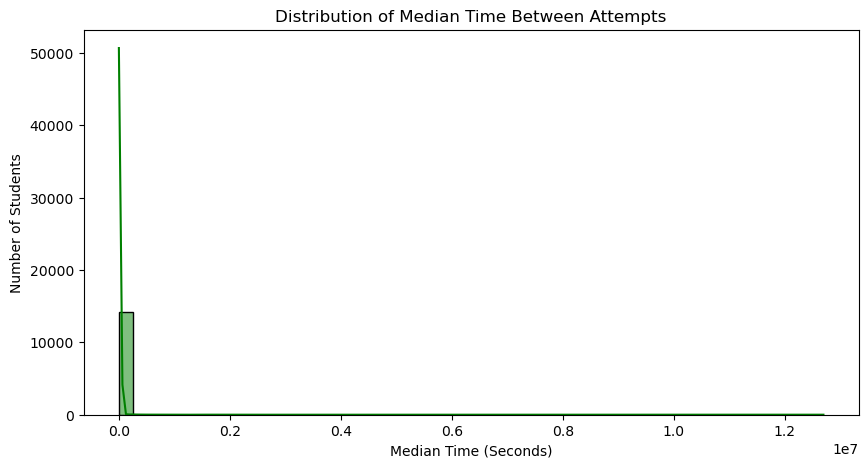

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=df_aggregated, x='median_time_between_attempts', bins=50, kde=True, color='green')

plt.title('Distribution of Median Time Between Attempts')
plt.xlabel('Median Time (Seconds)')
plt.ylabel('Number of Students')
plt.show()

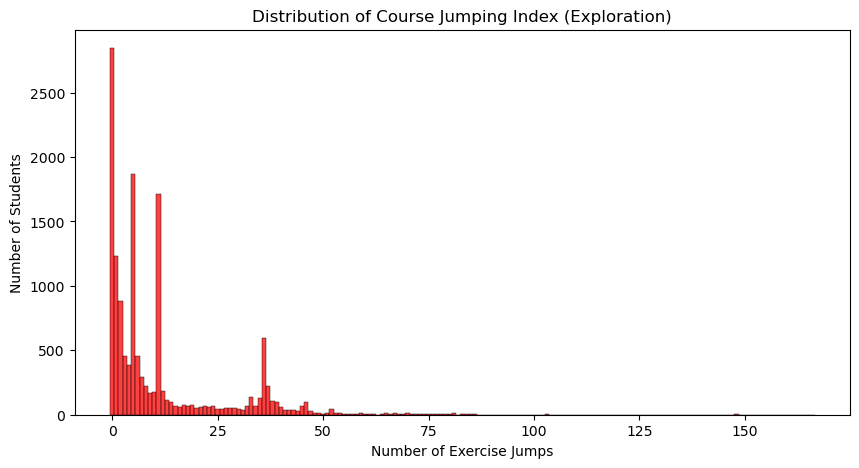

In [34]:

plt.figure(figsize=(10, 5))
sns.histplot(data=df_aggregated, x='course_jumping_index', discrete=True, color='red')

plt.title('Distribution of Course Jumping Index (Exploration)')
plt.xlabel('Number of Exercise Jumps')
plt.ylabel('Number of Students')
plt.show()

# Preprocessing

In [27]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Set user_id as index so it's not treated as a clustering feature
df_features = df_aggregated.set_index('user_id').copy()

# 2. Log-transform highly skewed features
# (Adding 1 to avoid log(0))
df_features['median_time_between_attempts'] = np.log1p(df_features['median_time_between_attempts'])
df_features['course_jumping_index'] = np.log1p(df_features['course_jumping_index'])



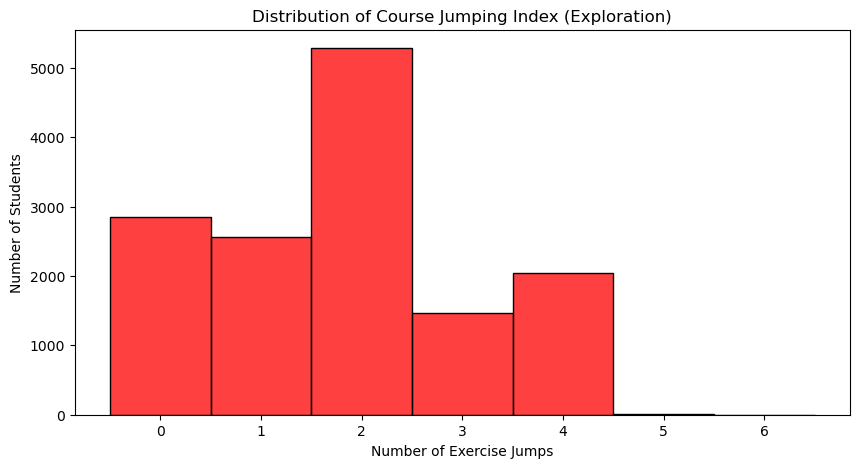

In [35]:

plt.figure(figsize=(10, 5))
sns.histplot(data=df_features, x='course_jumping_index', discrete=True, color='red')

plt.title('Distribution of Course Jumping Index (Exploration)')
plt.xlabel('Number of Exercise Jumps')
plt.ylabel('Number of Students')
plt.show()

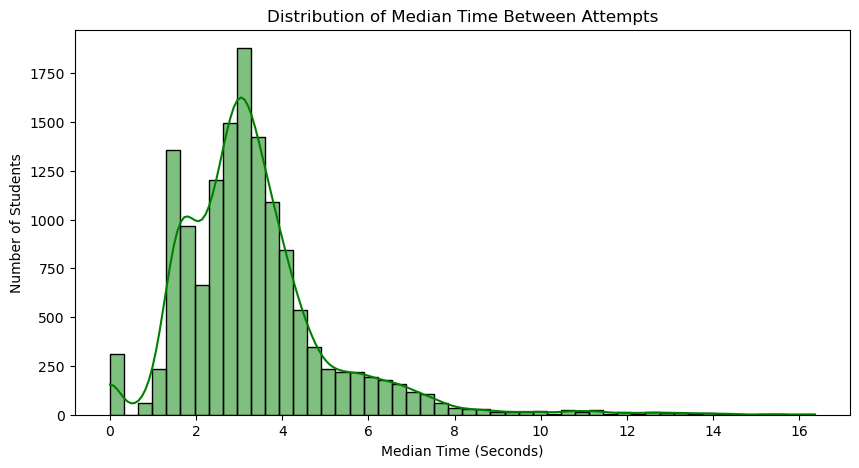

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_features, x='median_time_between_attempts', bins=50, kde=True, color='green')

plt.title('Distribution of Median Time Between Attempts')
plt.xlabel('Median Time (Seconds)')
plt.ylabel('Number of Students')
plt.show()

# Standardize all features

In [36]:
# 3. Standardize all features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_features)


In [38]:
# Convert scaled array back to a DataFrame for easier inspection
df_features_scaled = pd.DataFrame(
    features_scaled, 
    index=df_features.index, 
    columns=df_features.columns
)

print("Preprocessed features preview:")
print(df_features_scaled.head())

Preprocessed features preview:
            median_time_between_attempts  active_days_count  \
user_id                                                       
U_1002476                       0.053386          -0.565779   
U_10032370                      0.475661           1.079452   
U_1006467                       0.317967           1.079452   
U_1006581                       1.130129           1.079452   
U_1007135                       0.204710          -0.565779   

            avg_cognitive_dimension  score_maximization_ratio  \
user_id                                                         
U_1002476                 -0.607029                 -0.909577   
U_10032370                 1.615771                 -0.909577   
U_1006467                 -0.277273                  1.552396   
U_1006581                 -0.277273                  1.594844   
U_1007135                 -1.437525                 -0.060620   

            course_jumping_index  avg_attempts_per_problem  abandonment